In [2]:
#import libraries
import numpy as np 
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.layers import Input

In [3]:
#create sample time series data 
data = np.array([10,20,30,40,50,60,70,80,90,100])

In [6]:
#define functions time series data 
def create_sequences(data, seq_length):
    X,y=[], []
    for i in range(len(data) - seq_length):
      X.append(data[i:i+seq_length])
      y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [7]:
seq_length = 3
X, y = create_sequences(data, seq_length)
print("Input Sequences (X):")
print(X)
print("Target Output (y):")
print(y)

Input Sequences (X):
[[10 20 30]
 [20 30 40]
 [30 40 50]
 [40 50 60]
 [50 60 70]
 [60 70 80]
 [70 80 90]]
Target Output (y):
[ 40  50  60  70  80  90 100]


In [8]:
X = X.reshape((X.shape[0], X.shape[1], 1))
print("RNN Input Shape:", X.shape)

RNN Input Shape: (7, 3, 1)


In [9]:
#build rnn model
model = Sequential([
Input(shape=(seq_length, 1)),
SimpleRNN(50, activation='relu'),
Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# train the model
history = model.fit(X, y, epochs=200, verbose=1)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 5728.6353
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 5566.6304
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 5404.9458
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 5247.8359
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 5092.0322
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 4936.8169
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 4782.4492
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 4629.4243
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 4477.2290
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 4325.3008
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 4175.3027
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 4026.9575
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 3879.6404
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 3733.6987
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms

In [11]:
# make predictions 
predicted = model.predict(X)
print("Predicted Values:")
print(predicted.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
Predicted Values:
[ 30.142157  42.58013   55.033195  67.48627   79.93933   92.3924
 104.84546 ]


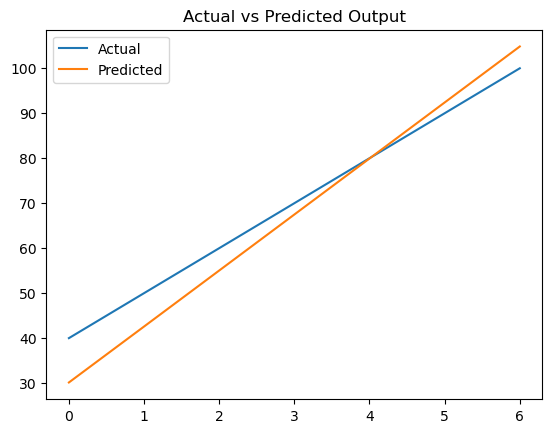

In [12]:
plt.plot(y, label='Actual')
plt.plot(predicted, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Output")
plt.show()